In [9]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

## Skenario Awal & Hasil yang Tampak Menjanjikan

In [24]:
# Generasi Data Awal yang terkontrol
# Kita sengaja membuat hubungan linear: pendapatan = 0.8 * iklan + 10 + noise
np.random.seed(42)
jumlah_hari = 30
pengeluaran_iklan = np.random.uniform(low=50, high=150, size=jumlah_hari)
# np.random.normal mensimulasikan faktor-faktor acak lain yang memengaruhi penjualan
pendapatan_penjualan = (0.8 * pengeluaran_iklan) + 10 + np.random.normal(0, 15, size=jumlah_hari)
df = pd.DataFrame({'pengeluaran_iklan': pengeluaran_iklan, 'pendapatan_penjualan': pendapatan_penjualan})

# Kalkulasi & Visualisasi Awal
r_value, p_value = pearsonr(df['pengeluaran_iklan'], df['pendapatan_penjualan'])

# Mencetak hasil agar lebih jelas
print(f"Koefisien Korelasi Pearson (r): {r_value:.4f}")
print(f"P-value: {p_value:.4f}")


Koefisien Korelasi Pearson (r): 0.8003
P-value: 0.0000


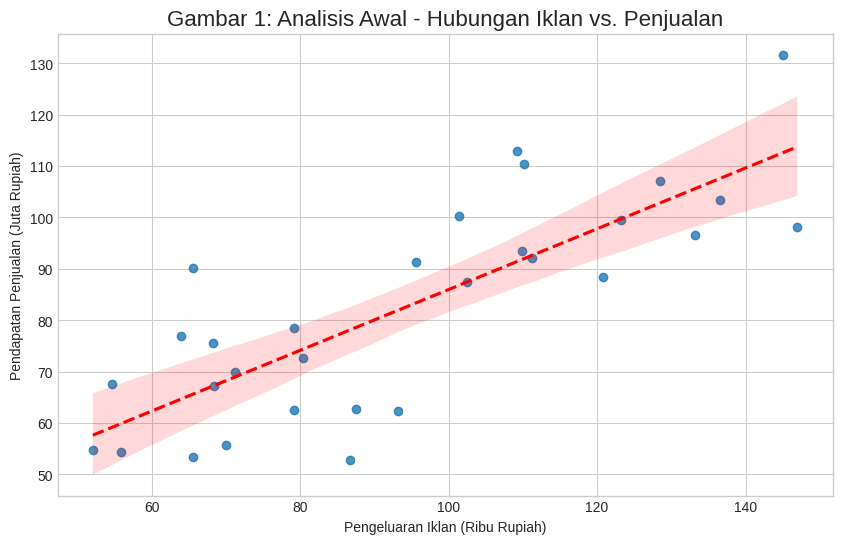

In [25]:
# Visualisasi
plt.figure(figsize=(10, 6))
sns.regplot(x='pengeluaran_iklan', y='pendapatan_penjualan', data=df, line_kws={'color':'red', 'linestyle':'--'})
plt.title('Analisis Awal - Hubungan Iklan vs. Penjualan', fontsize=16)
plt.xlabel('Pengeluaran Iklan (Ribu Rupiah)')
plt.ylabel('Pendapatan Penjualan (Juta Rupiah)')
plt.grid(True)
plt.show()

## Checklist Validasi Kritis

### Pemeriksaan Asumsi Linearitas

#### a. Inspeksi Visual (Scatter Plot): 

In [4]:
# Membuat data dengan hubungan kuadratik (berbentuk U)
np.random.seed(0)
x_nonlinear = np.linspace(-10, 10, 100)
y_nonlinear = x_nonlinear**2 + np.random.normal(0, 5, 100)

Korelasi Pearson pada data kuadratik: -0.0133


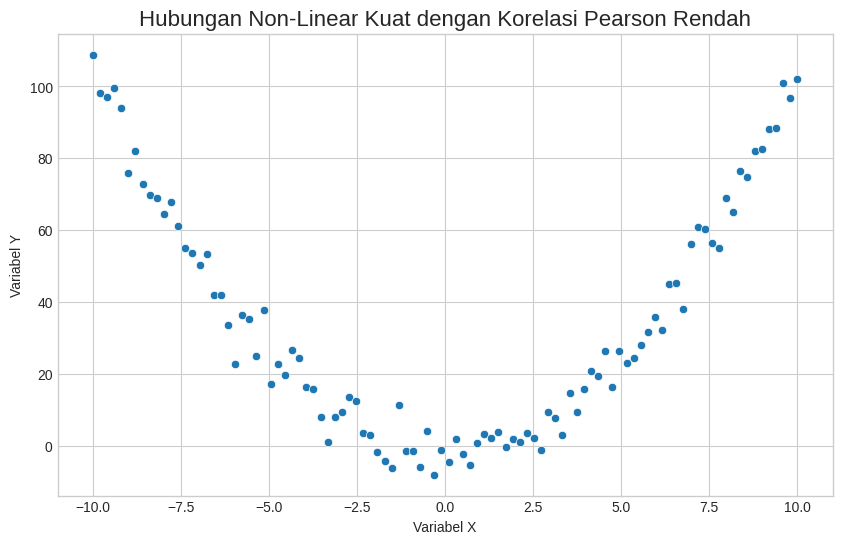

In [28]:
# Menghitung korelasi Pearson yang menyesatkan
r_nonlinear, _ = pearsonr(x_nonlinear, y_nonlinear)
print(f"Korelasi Pearson pada data kuadratik: {r_nonlinear:.4f}")

# Visualisasi
plt.figure(figsize=(10, 6))
sns.scatterplot(x=x_nonlinear, y=y_nonlinear)
plt.title('Hubungan Non-Linear Kuat dengan Korelasi Pearson Rendah', fontsize=16)
plt.xlabel('Variabel X')
plt.ylabel('Variabel Y')
plt.grid(True)
plt.show()


#### b. Analisis Plot Residual

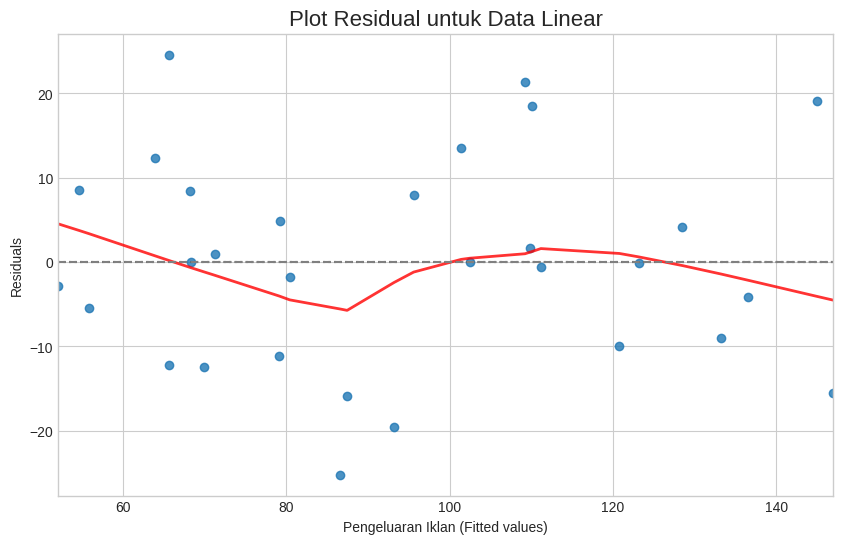

In [29]:
# Menggunakan data awal kita yang memang linear (df)
plt.figure(figsize=(10, 6))
sns.residplot(x='pengeluaran_iklan', y='pendapatan_penjualan', data=df, lowess=True,
              line_kws=dict(color="red", lw=2, alpha=0.8))
plt.title('Plot Residual untuk Data Linear', fontsize=16)
plt.xlabel('Pengeluaran Iklan (Fitted values)')
plt.ylabel('Residuals')
plt.grid(True)
plt.axhline(0, color='grey', linestyle='--')
plt.show()


#### c. Uji Statistik Formal (ANOVA Lack-of-Fit Test)

In [12]:

# Data non-linear (kuadratik)
np.random.seed(3)
x_nonlinear = np.linspace(-10, 10, 100)
y_nonlinear = x_nonlinear**2 + np.random.normal(0, 5, 100)
df_nonlinear = pd.DataFrame({'x': x_nonlinear, 'y': y_nonlinear})

# Data linear (iklan vs penjualan)
np.random.seed(42)
pengeluaran_iklan = np.random.uniform(50, 150, 30)
pendapatan_penjualan = 0.8 * pengeluaran_iklan + 10 + np.random.normal(0, 15, 30)
df_linear = pd.DataFrame({'pengeluaran_iklan': pengeluaran_iklan,
                          'pendapatan_penjualan': pendapatan_penjualan})


# ================================
# UJI ANOVA
# ================================
print("--- Uji Linearitas: Data Non-Linear ---")
df_nonlinear['x_binned'] = pd.cut(df_nonlinear['x'], bins=10)
linear_model_nl = ols('y ~ x', data=df_nonlinear).fit()
nonlinear_model_nl = ols('y ~ x_binned', data=df_nonlinear).fit()
print(sm.stats.anova_lm(linear_model_nl, nonlinear_model_nl))

print("\n" + "="*50 + "\n")

print("--- Uji Linearitas: Data Linear ---")
df_linear['iklan_binned'] = pd.cut(df_linear['pengeluaran_iklan'], bins=5)
linear_model_l = ols('pendapatan_penjualan ~ pengeluaran_iklan', data=df_linear).fit()
nonlinear_model_l = ols('pendapatan_penjualan ~ iklan_binned', data=df_linear).fit()
print(sm.stats.anova_lm(linear_model_l, nonlinear_model_l))


--- Uji Linearitas: Data Non-Linear ---
   df_resid           ssr  df_diff       ss_diff           F        Pr(>F)
0      98.0  95964.032473      0.0           NaN         NaN           NaN
1      90.0   7926.653259      8.0  88037.379214  124.948132  2.467946e-45


--- Uji Linearitas: Data Linear ---
   df_resid          ssr  df_diff     ss_diff         F    Pr(>F)
0      28.0  4533.730894      0.0         NaN       NaN       NaN
1      25.0  3848.877461      3.0  684.853433  1.482799  0.243326


### Identifikasi Outlier yang Berpengaruh

Korelasi Asli: 0.8003
Korelasi dengan Outlier: 0.3656


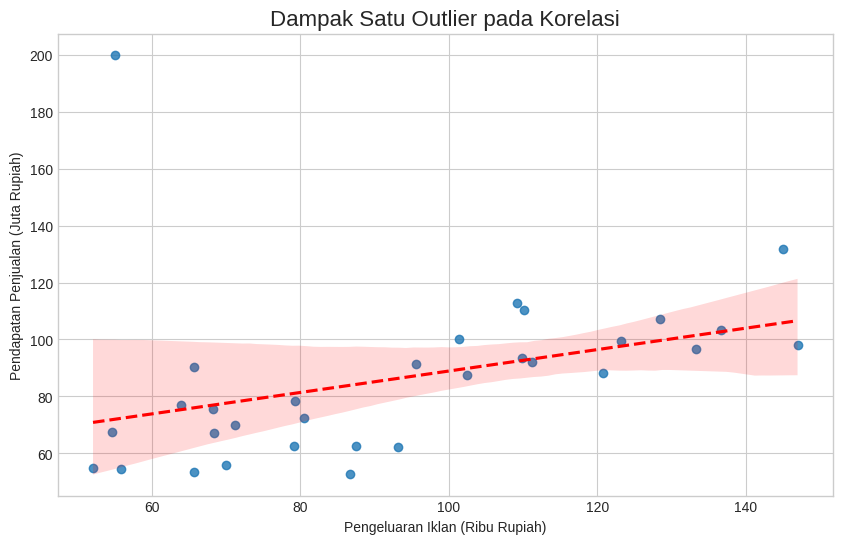

In [32]:
# Menambahkan outlier buatan dan menghitung ulang
df_with_outlier = df.copy()
# Misalkan ada hari di mana iklan hanya 55 ribu tapi penjualan meroket jadi 200 juta
df_with_outlier.loc[len(df_with_outlier)] = [55, 200] 
r_outlier, p_outlier = pearsonr(df_with_outlier['pengeluaran_iklan'], df_with_outlier['pendapatan_penjualan'])

print(f"Korelasi Asli: {r_value:.4f}")
print(f"Korelasi dengan Outlier: {r_outlier:.4f}")

# Visualisasi dampak outlier
plt.figure(figsize=(10, 6))
sns.regplot(x='pengeluaran_iklan', y='pendapatan_penjualan', data=df_with_outlier, line_kws={'color':'red', 'linestyle':'--'})
plt.title('Dampak Satu Outlier pada Korelasi', fontsize=16)
plt.xlabel('Pengeluaran Iklan (Ribu Rupiah)')
plt.ylabel('Pendapatan Penjualan (Juta Rupiah)')
plt.grid(True)
plt.show()


### Waspadai Pengaruh Pembatasan Rentang (Range Restriction)

Korelasi Asli (seluruh rentang): 0.8003
Korelasi pada Rentang Terbatas: 0.8174


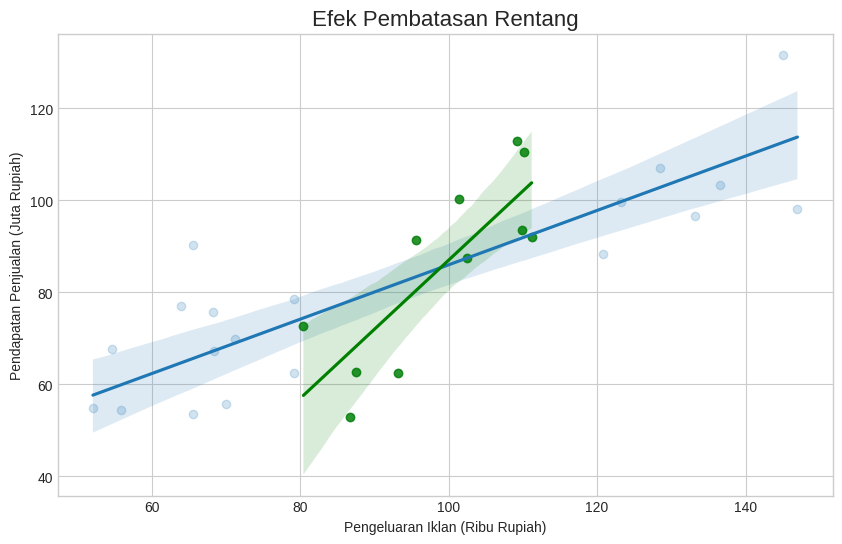

In [33]:
# Memfilter data ke rentang yang sempit
df_restricted = df[(df['pengeluaran_iklan'] >= 80) & (df['pengeluaran_iklan'] <= 120)]
r_restricted, _ = pearsonr(df_restricted['pengeluaran_iklan'], df_restricted['pendapatan_penjualan'])

print(f"Korelasi Asli (seluruh rentang): {r_value:.4f}")
print(f"Korelasi pada Rentang Terbatas: {r_restricted:.4f}")

# Visualisasi pembatasan rentang
plt.figure(figsize=(10, 6))
sns.regplot(x='pengeluaran_iklan', y='pendapatan_penjualan', data=df, scatter_kws={'alpha':0.2}) # Data asli dibuat transparan
sns.regplot(x='pengeluaran_iklan', y='pendapatan_penjualan', data=df_restricted, scatter_kws={'color':'green'}, line_kws={'color':'green'})
plt.title('Efek Pembatasan Rentang', fontsize=16)
plt.xlabel('Pengeluaran Iklan (Ribu Rupiah)')
plt.ylabel('Pendapatan Penjualan (Juta Rupiah)')
plt.grid(True)
plt.show()


### Hati-hati dengan Paradoks Simpson

#### a. Generasi Data & Perhitungan

In [47]:

np.random.seed(231)

# Platform A: Budget rendah, korelasi internal negatif
iklan_A = np.random.uniform(20, 60, 50)
penjualan_A = 100 - (1.5 * iklan_A) + np.random.normal(0, 8, 50)


df_A = pd.DataFrame({'iklan': iklan_A, 'penjualan': penjualan_A, 'platform': 'Platform A'})

# Platform B: Budget tinggi, korelasi internal juga negatif.
iklan_B = np.random.uniform(70, 110, 50)
penjualan_B = 250 - (1.5 * iklan_B) + np.random.normal(0, 8, 50)
df_B = pd.DataFrame({'iklan': iklan_B, 'penjualan': penjualan_B, 'platform': 'Platform B'})

# Gabungkan data
df_simpson = pd.concat([df_A, df_B])

# 1. Hitung korelasi pada data agregat (keseluruhan)
r_total, _ = pearsonr(df_simpson['iklan'], df_simpson['penjualan'])

# 2. Hitung korelasi per sub-kelompok
r_A, _ = pearsonr(df_A['iklan'], df_A['penjualan'])
r_B, _ = pearsonr(df_B['iklan'], df_B['penjualan'])

print(f"Korelasi Agregat (Keseluruhan): {r_total:.4f}")
print("-" * 35)
print(f"Korelasi untuk Platform A: {r_A:.4f}")
print(f"Korelasi untuk Platform B: {r_B:.4f}")


Korelasi Agregat (Keseluruhan): 0.6028
-----------------------------------
Korelasi untuk Platform A: -0.9488
Korelasi untuk Platform B: -0.8957


#### b. Visualisasi Paradoks:

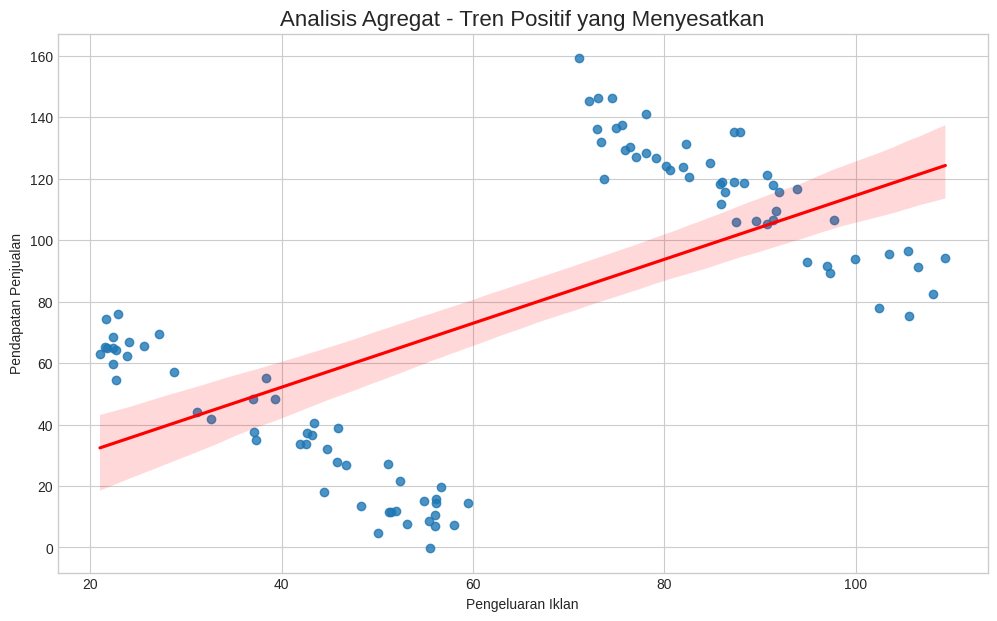

In [48]:
# Plot 1: Tren Agregat yang Menyesatkan
plt.figure(figsize=(12, 7))
sns.regplot(x='iklan', y='penjualan', data=df_simpson, line_kws={'color':'red'})
plt.title('Analisis Agregat - Tren Positif yang Menyesatkan', fontsize=16)
plt.xlabel('Pengeluaran Iklan')
plt.ylabel('Pendapatan Penjualan')
plt.grid(True)
plt.show()


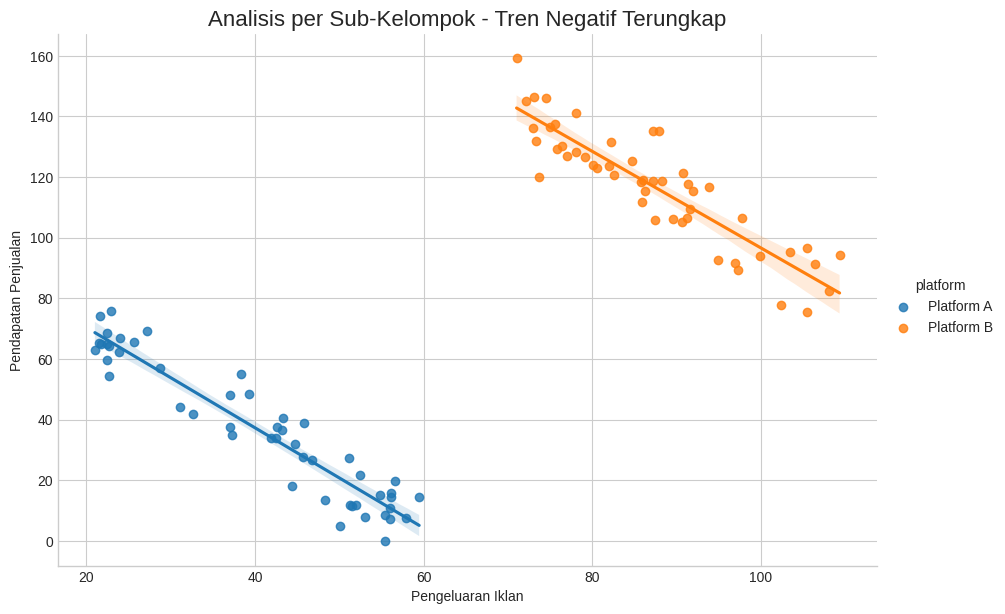

In [49]:
# Plot 2: Tren Sebenarnya Setelah Dibagi per Platform
# lmplot dari seaborn sangat ideal untuk ini
sns.lmplot(x='iklan', y='penjualan', hue='platform', data=df_simpson, height=6, aspect=1.5)
plt.title('Analisis per Sub-Kelompok - Tren Negatif Terungkap', fontsize=16)
plt.xlabel('Pengeluaran Iklan')
plt.ylabel('Pendapatan Penjualan')
plt.grid(True)
plt.show()